# Car Price Prediction with Machine Learning

## Oasis Infobyte Data Science Internship

### Task 3

**Author:** Harshit Raj Gupta

## Objective

The objective of this project is to build a machine learning regression model that predicts the selling price of used cars based on features such as brand, car age, fuel type, transmission, seller type, and kilometers driven.

## Import Required Libraries

The following libraries are imported for data manipulation, visualization, preprocessing, machine learning, and model evaluation.

In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Upload the Dataset

The CarDekho dataset is uploaded into the Google Colab environment using the `files.upload()` function. This allows the notebook to access the dataset for further analysis.

In [50]:
from google.colab import files

uploaded = files.upload()

Saving cardekho.csv to cardekho (1).csv


## Load the Dataset

After uploading, the dataset is loaded into a pandas DataFrame for inspection, cleaning, and further analysis.

In [51]:
import os

print(os.listdir("/content"))

['.config', 'cardekho (1).csv', 'cardekho.csv', 'sample_data']


In [52]:
df = pd.read_csv("cardekho.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


## Data Cleaning

The dataset is inspected for missing values, duplicate records, and inconsistent categorical values. Cleaning the data ensures that it is suitable for machine learning and improves model performance.

In [53]:
print("Dataset Shape:", df.shape)

Dataset Shape: (8128, 12)


In [54]:
df.dtypes

,0
name,object
year,int64
selling_price,int64
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object
mileage(km/ltr/kg),float64
engine,float64


In [55]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),221
engine,221


In [56]:
df = df.drop_duplicates()

print("Dataset Shape after removing duplicates:", df.shape)

Dataset Shape after removing duplicates: (6926, 12)


In [57]:
categorical_columns = [
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

for column in categorical_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.title()
    )

df[categorical_columns].head()

,fuel,seller_type,transmission,owner
0,Diesel,Individual,Manual,First Owner
1,Diesel,Individual,Manual,Second Owner
2,Petrol,Individual,Manual,Third Owner
3,Diesel,Individual,Manual,First Owner
4,Petrol,Individual,Manual,First Owner


In [58]:
df.describe(include="all")

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
count,6926,6926.000000,6.926000e+03,6.926000e+03,6926,6926,6926,6926,6718.00000,6718.000000,6721,6718.000000
unique,2058,NaN,NaN,NaN,4,3,2,5,NaN,NaN,320,NaN
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,Diesel,Individual,Manual,First Owner,NaN,NaN,74,NaN
freq,118,NaN,NaN,NaN,3755,6218,6342,4242,NaN,NaN,324,NaN
mean,NaN,2013.420300,5.172707e+05,7.399568e+04,NaN,NaN,NaN,NaN,19.46531,1430.891337,NaN,5.434653
std,NaN,4.078286,5.197670e+05,5.835810e+04,NaN,NaN,NaN,NaN,4.04915,493.493277,NaN,0.984230
min,NaN,1983.000000,2.999900e+04,1.000000e+00,NaN,NaN,NaN,NaN,0.00000,624.000000,NaN,2.000000
25%,NaN,2011.000000,2.500000e+05,4.000000e+04,NaN,NaN,NaN,NaN,16.80000,1197.000000,NaN,5.000000
50%,NaN,2014.000000,4.000000e+05,7.000000e+04,NaN,NaN,NaN,NaN,19.44000,1248.000000,NaN,5.000000
75%,NaN,2017.000000,6.335000e+05,1.000000e+05,NaN,NaN,NaN,NaN,22.50000,1498.000000,NaN,5.000000


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                6926 non-null   object 
 1   year                6926 non-null   int64  
 2   selling_price       6926 non-null   int64  
 3   km_driven           6926 non-null   int64  
 4   fuel                6926 non-null   object 
 5   seller_type         6926 non-null   object 
 6   transmission        6926 non-null   object 
 7   owner               6926 non-null   object 
 8   mileage(km/ltr/kg)  6718 non-null   float64
 9   engine              6718 non-null   float64
 10  max_power           6721 non-null   object 
 11  seats               6718 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 703.4+ KB


## Feature Engineering

Feature engineering is performed to create new useful features from the existing dataset. The car age is calculated from the manufacturing year, and the vehicle brand is extracted from the car name.

In [60]:
current_year = 2026

df["car_age"] = current_year - df["year"]

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0,12
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,12
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0,20
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0,16
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0,19


In [61]:
df["brand"] = df["name"].str.split().str[0]

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0,12,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,12,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0,20,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0,16,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0,19,Maruti


In [62]:
df[["name", "brand", "year", "car_age"]].head()

,name,brand,year,car_age
0,Maruti Swift Dzire VDI,Maruti,2014,12
1,Skoda Rapid 1.5 TDI Ambition,Skoda,2014,12
2,Honda City 2017-2020 EXi,Honda,2006,20
3,Hyundai i20 Sportz Diesel,Hyundai,2010,16
4,Maruti Swift VXI BSIII,Maruti,2007,19


In [63]:
# Clean max_power column

df["max_power"] = (
    df["max_power"]
    .astype(str)
    .str.replace("bhp", "", regex=False)
    .str.strip()
)

df["max_power"] = pd.to_numeric(
    df["max_power"],
    errors="coerce"
)

df["max_power"] = df["max_power"].fillna(
    df["max_power"].median()
)

df["max_power"].head()

,max_power
0,74.00
1,103.52
2,78.00
3,90.00
4,88.20


In [64]:
# Clean engine column

df["engine"] = (
    df["engine"]
    .astype(str)
    .str.replace("CC", "", regex=False)
    .str.strip()
)

df["engine"] = pd.to_numeric(
    df["engine"],
    errors="coerce"
)

df["engine"] = df["engine"].fillna(
    df["engine"].median()
)

In [65]:
# Clean mileage column

df["mileage(km/ltr/kg)"] = pd.to_numeric(
    df["mileage(km/ltr/kg)"],
    errors="coerce"
)

df["mileage(km/ltr/kg)"] = df["mileage(km/ltr/kg)"].fillna(
    df["mileage(km/ltr/kg)"].median()
)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                6926 non-null   object 
 1   year                6926 non-null   int64  
 2   selling_price       6926 non-null   int64  
 3   km_driven           6926 non-null   int64  
 4   fuel                6926 non-null   object 
 5   seller_type         6926 non-null   object 
 6   transmission        6926 non-null   object 
 7   owner               6926 non-null   object 
 8   mileage(km/ltr/kg)  6926 non-null   float64
 9   engine              6926 non-null   float64
 10  max_power           6926 non-null   float64
 11  seats               6718 non-null   float64
 12  car_age             6926 non-null   int64  
 13  brand               6926 non-null   object 
dtypes: float64(4), int64(4), object(6)
memory usage: 811.6+ KB


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distribution of selling prices and the relationship between selling price and important vehicle features.

## Distribution of Selling Prices

The distribution plot helps understand how the selling prices of used cars are spread across the dataset.

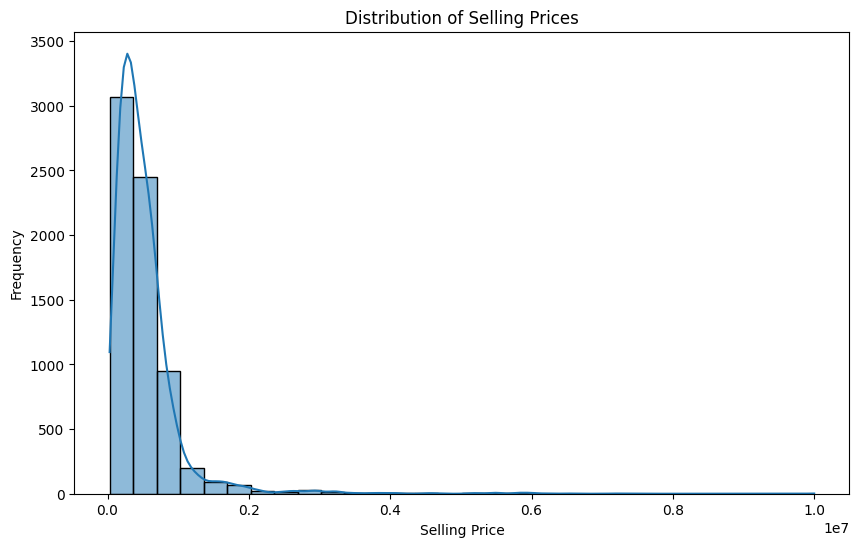

In [67]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["selling_price"],
    bins=30,
    kde=True
)

plt.title("Distribution of Selling Prices")

plt.xlabel("Selling Price")

plt.ylabel("Frequency")

plt.show()

### Observation

The histogram illustrates the distribution of car selling prices. It helps identify whether the prices are normally distributed or skewed towards lower or higher price ranges.

## Selling Price vs Fuel Type

This box plot compares the selling price of cars across different fuel types.

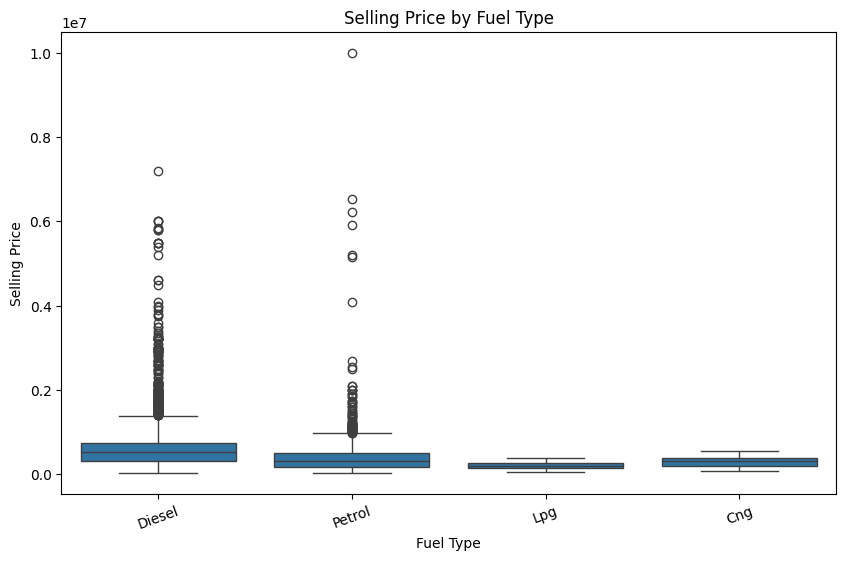

In [68]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")

plt.xlabel("Fuel Type")

plt.ylabel("Selling Price")

plt.xticks(rotation=20)

plt.show()

### Observation

The box plot shows how selling prices vary among different fuel types. It also highlights the spread of prices and potential outliers within each category.

## Selling Price vs Car Age

The relationship between the age of a car and its selling price is analyzed using a scatter plot.

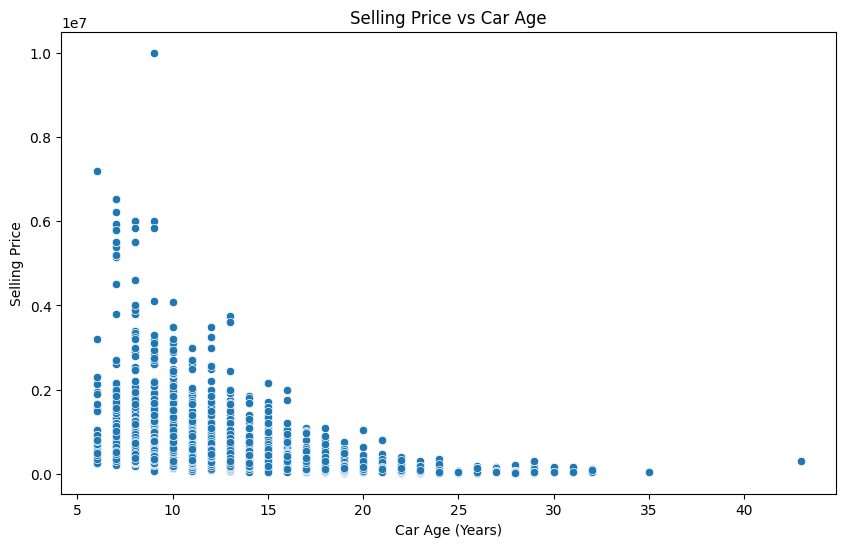

In [69]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="car_age",
    y="selling_price"
)

plt.title("Selling Price vs Car Age")

plt.xlabel("Car Age (Years)")

plt.ylabel("Selling Price")

plt.show()

### Observation

The scatter plot shows the relationship between car age and selling price. In general, older cars tend to have lower selling prices, although some variations exist depending on other vehicle characteristics.

# Data Preprocessing

Before training machine learning models, categorical variables are encoded using One-Hot Encoding. The dataset is then divided into training and testing sets.

In [70]:
# Select features and target variable

X = df.drop(
    columns=[
        "selling_price",
        "name",
        "year"
    ]
)

y = df["selling_price"]

X.head()

,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age,brand
0,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,12,Maruti
1,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,12,Skoda
2,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,20,Honda
3,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,16,Hyundai
4,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,19,Maruti


## One-Hot Encoding

Categorical variables are converted into numerical format using One-Hot Encoding so that machine learning models can process them.

In [71]:
categorical_features = [
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "brand"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

## Feature Correlation Heatmap

The heatmap helps visualize the correlation between numerical variables in the dataset.

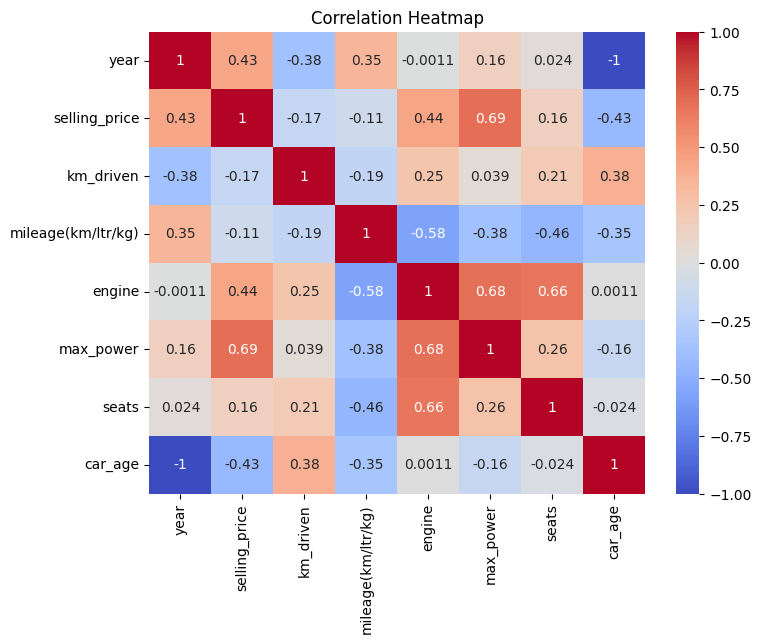

In [72]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap illustrates the relationships among numerical features. Strong positive or negative correlations indicate variables that may significantly influence the selling price.

## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio to evaluate model performance on unseen data.

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (5540, 11)
Testing Samples: (1386, 11)


# Model 1: Linear Regression

In [74]:
# Check for empty strings in all columns

for column in df.columns:
    empty_count = (df[column].astype(str).str.strip() == "").sum()
    if empty_count > 0:
        print(f"{column}: {empty_count} empty values")

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                6926 non-null   object 
 1   year                6926 non-null   int64  
 2   selling_price       6926 non-null   int64  
 3   km_driven           6926 non-null   int64  
 4   fuel                6926 non-null   object 
 5   seller_type         6926 non-null   object 
 6   transmission        6926 non-null   object 
 7   owner               6926 non-null   object 
 8   mileage(km/ltr/kg)  6926 non-null   float64
 9   engine              6926 non-null   float64
 10  max_power           6926 non-null   float64
 11  seats               6718 non-null   float64
 12  car_age             6926 non-null   int64  
 13  brand               6926 non-null   object 
dtypes: float64(4), int64(4), object(6)
memory usage: 811.6+ KB


In [76]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,12,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,12,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,20,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,16,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,19,Maruti


In [77]:
print(df.isnull().sum())

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)      0
engine                  0
max_power               0
seats                 208
car_age                 0
brand                   0
dtype: int64


In [78]:
# Fill missing values in seats column

df["seats"] = df["seats"].fillna(df["seats"].median())

In [79]:
print(df.isnull().sum())

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
car_age               0
brand                 0
dtype: int64


In [80]:
X = df.drop(columns=["selling_price", "name", "year"])
y = df["selling_price"]

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [82]:
print(X_train.isnull().sum())

km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
car_age               0
brand                 0
dtype: int64


In [83]:
linear_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_pipeline.fit(X_train, y_train)

linear_predictions = linear_pipeline.predict(X_test)

# Model Evaluation: Linear Regression

The Linear Regression model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score to measure its prediction performance.

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Performance")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression Performance
MAE : 167801.87028643058
RMSE: 298169.09093201876
R² Score: 0.5946373022968752


# Model 2: Random Forest Regressor

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions to improve regression accuracy.

In [85]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_predictions = rf_pipeline.predict(X_test)

# Model Evaluation: Random Forest

The Random Forest model is evaluated using the same metrics as Linear Regression for a fair comparison.

In [86]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Performance
MAE : 73370.66560823083
RMSE: 128427.79023681769
R² Score: 0.9247967587320646


# Model Comparison

The performance of both regression models is compared using MAE, RMSE, and R² Score.

In [87]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,167801.870286,298169.090932,0.594637
1,Random Forest,73370.665608,128427.790237,0.924797


# Best Model

The model with the higher R² Score and lower MAE and RMSE is selected as the best-performing regression model.

# Feature Importance

Feature importance shows which variables have the greatest influence on predicting the selling price of a used car. This helps understand the most significant factors affecting the model's predictions.

In [88]:
# Get feature names after preprocessing

feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance values

importance = rf_pipeline.named_steps["model"].feature_importances_

# Create DataFrame

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort values

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
47,remainder__max_power,0.600889
49,remainder__car_age,0.230124
44,remainder__km_driven,0.044778
45,remainder__mileage(km/ltr/kg),0.038393
46,remainder__engine,0.023162
48,remainder__seats,0.008499
33,cat__brand_Mercedes-Benz,0.005963
41,cat__brand_Toyota,0.005447
16,cat__brand_BMW,0.004176
40,cat__brand_Tata,0.004111


## Top 10 Important Features

The table above shows the ten most influential features used by the Random Forest model for predicting car selling prices.

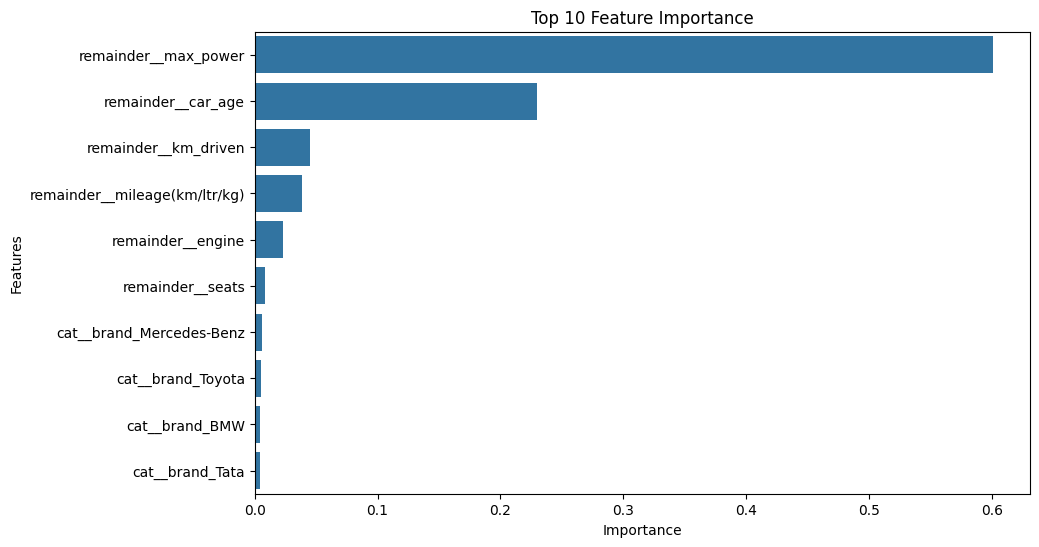

In [89]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

# Final Conclusion

This project developed two regression models to predict the selling price of used cars.

- Data preprocessing included handling missing values, removing duplicates, feature engineering, and encoding categorical variables.
- Exploratory Data Analysis (EDA) was performed to understand the dataset.
- Linear Regression and Random Forest Regressor were trained and evaluated using MAE, RMSE, and R² Score.
- Random Forest Regressor achieved the highest R² Score and the lowest prediction errors, making it the best-performing model.
- Feature importance analysis identified the most influential factors affecting car prices.